In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import importlib
import pandas as pd
from datetime import datetime
from tqdm import tqdm
from plotly.subplots import make_subplots
from plotly import tools
import plotly.offline as pyo
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import glob
import math
from scipy import stats
import uproot
from ROOT import TFile, TEfficiency, TH1D, TGraphAsymmErrors, RDataFrame, TCanvas

c++: error: argument to '-isysroot' is missing (expected 1 value)
c++: error: no input files
ERROR in cling::CIFactory::createCI(): cannot extract standard library include paths!
Invoking:
  LC_ALL=C /Applications/Xcode.app/Contents/Developer/Toolchains/XcodeDefault.xctoolchain/usr/bin/c++ -isysroot;/Applications/Xcode.app/Contents/Developer/Platforms/MacOSX.platform/Developer/SDKs/MacOSX15.1.sdk   -xc++ -E -v /dev/null 2>&1 | sed -n -e '/^.include/,${' -e '/^ \/.*++/p' -e '}'
Results was:
c++: error: argument to '-isysroot' is missing (expected 1 value)
c++: error: no input files
With exit code 0


In [67]:
file = uproot.open('/Users/danielcarber/Documents/ICARUS/nue_mc.root')
print(file.keys())

['events;1', 'events/mc;1', 'events/mc/POT;3', 'events/mc/POT;2', 'events/mc/POT;1', 'events/mc/Livetime;3', 'events/mc/Livetime;2', 'events/mc/Livetime;1', 'events/mc/SelectedNu_Cuts;1', 'events/mc/SelectedCos_PhaseCuts;1', 'events/mc/Efficiency_PhaseCuts;1']


In [68]:
mc_df = file['events/mc/Efficiency_PhaseCuts;1']
mc_df=mc_df.arrays(library='pd')



print(mc_df.keys())
print(mc_df['true_Q'][0])


Index(['all_1eNp_cut', 'category_topology', 'fiducial_cut', 'flash_cut',
       'nu_id', 'reco_Q', 'reco_W', 'reco_alphaT', 'reco_dpT',
       'reco_electron_axial_spread', 'reco_electron_conv_dist',
       'reco_electron_dir_spread', 'reco_electron_energy',
       'reco_electron_pT_mag', 'reco_electron_polar',
       'reco_electron_straightness', 'reco_opening_angle', 'reco_phiT',
       'reco_proton_energy', 'reco_proton_muon_softmax',
       'reco_proton_pion_softmax', 'reco_proton_polar', 'reco_proton_softmax',
       'reco_topology', 'track_containment_cut', 'true_Q', 'true_W',
       'true_alphaT', 'true_dpT', 'true_electron_energy',
       'true_electron_pT_mag', 'true_electron_polar', 'true_opening_angle',
       'true_phiT', 'true_proton_energy', 'true_proton_polar', 'true_topology',
       'Run', 'Subrun', 'Evt'],
      dtype='object')
975365.6517968032


In [69]:
quality_cuts = (mc_df['category_topology']==0)|(mc_df['category_topology']==1)
signal = mc_df[quality_cuts]
#mask  = (signal['track_containment_cut']==1)
signal = signal

efficiency = len(signal)/(len(mc_df[quality_cuts]))
print(f"Eff of Containment: {efficiency*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df[quality_cuts])}")

Eff of Containment: 100.00%
Number of Signal and Total: 7044, 7044


In [70]:
def bin_uncertainty(k, N):
    #N is the total number within the bin
    #k is the number of selected in bin
    #print(k,":",N)


    uncertainty = []
    normalize = math.exp(math.lgamma(N+2)-math.lgamma(1)-math.lgamma(N+1))*np.power(1,N)
    eff = np.arange(0, 1, 0.0001).tolist()
    a = math.exp(math.lgamma(N+2)-math.lgamma(k+1)-math.lgamma(N-k+1))
    b = np.power(eff,k)*np.power([1-x for x in eff],N-k)


    
    prob = b*a
    prob = list(np.divide(prob,normalize))

    prob_max_index = prob.index(max(prob))
    prob_max = max(prob)
    if k==0:
        for i in range(int(len(prob)/2)):
            percentage = sum(prob[prob_max_index:prob_max_index+i])/sum(prob)
            if percentage >.68:
                uncertainty= [0,abs(eff[prob_max_index+i]-k/N)]
                break
    elif k==N:
        for i in range(int(len(prob)/2)):
            percentage = sum(prob[prob_max_index-i:prob_max_index])/sum(prob)
            if percentage >.68:
                uncertainty= [abs(eff[prob_max_index-i]-k/N),0]
                break
    else:
        for i in range(int(prob_max*1000)):
            j=prob_max-(i/1000)
            diff_r = np.array([np.absolute(x - j) for x in prob[prob_max_index:]])
            diff_l = np.array([np.absolute(x - j) for x in prob[:prob_max_index]])
            index_r = diff_r.argmin()
            index_l = diff_l.argmin()
            percentage = sum(prob[index_l:prob_max_index+index_r])/sum(prob)
            if percentage >.68:
                
                uncertainty= [abs(eff[index_l]-k/N),abs(eff[prob_max_index+index_r]-k/N)]
                break
            else:
                uncertainty= [abs(eff[index_l]-k/N),abs(eff[prob_max_index+index_r]-k/N)]
    return uncertainty

In [71]:
def get_eff_bins(df,df_cut,variable ,bins = [0,1000,1]):
    step = 0
    eff_bins,var_bins, unc_bins = [],[],[]
    bins[2] = bins[2]/2
    while step+bins[0] < bins[1]:
        mask = (df[variable] >=bins[0]+step) & (df[variable] <bins[0]+step+bins[2])
        mask_cut = (df_cut[variable] >=bins[0]+step) & (df_cut[variable] <bins[0]+step+bins[2])
        num_bin = sum(mask_cut)
        den_bin = sum(mask)
        uncertainty = bin_uncertainty(num_bin, den_bin)
        if den_bin == 0:
            eff_bins.append(1)
            unc_bins.append([0,0])
            
        else:
            eff_bins.append(num_bin/den_bin)
            unc_bins.append(uncertainty)

        var_bins.append(bins[0]+step+(bins[2]/2))

        step += bins[2]
    bins[2] = bins[2]*2
    return eff_bins, var_bins, unc_bins

In [72]:
def get_eff_bins_same(df,df_cut,variable ,bins = [0,1000,10]):
    step = 0
    eff_bins,var_bins, unc_bins = [],[],[]
    df = df.sort_values(by=variable, ascending=True)
    df_cut = df_cut.sort_values(by=variable, ascending=True)
    for i in tqdm(range(0, int(len(df_cut)),bins[2])):
        #print(i+bins[2],int(len(df_cut)))
        if i+bins[2] > int(len(df_cut)):
            high_bin = df_cut[variable].iloc[int(len(df_cut))-1]
        else:
            high_bin = df_cut[variable].iloc[i+bins[2]]
                                                 
        #print(df_cut[variable].iloc[i],df_cut[variable].iloc[i+bins[2]])
        low_bin = df_cut[variable].iloc[i]
        
        mask = (df[variable]>= low_bin) & (df[variable]< high_bin)
        mask_cut = (df_cut[variable]>= low_bin) & (df_cut[variable]< high_bin)
        num_bin = sum(mask_cut)
        den_bin = sum(mask)
        uncertainty = bin_uncertainty(num_bin, den_bin)

        eff_bins.append(num_bin/den_bin)
        unc_bins.append(uncertainty)

        var_bins.append([low_bin,high_bin])
    return eff_bins, var_bins, unc_bins

In [73]:
def cut_eff_bins(df,df_cut,variable ,bins = [0,1000,1]):
    step = 0
    eff_bins,var_bins = [],[]
    while step+bins[0] < bins[1]:
        mask = (df[variable] >=bins[0]+step) & (df[variable] <bins[0]+step+bins[2])
        mask_cut = (df_cut[variable] >=bins[0]+step) & (df_cut[variable] <bins[0]+step+bins[2])
        num_bin = sum(mask_cut)
        den_bin = sum(mask)
        if den_bin == 0:
            eff_bins.append(None)
        else:
            eff_bins.append(num_bin/den_bin)
        var_bins.append(bins[0]+step+(bins[2]/2))
        step += bins[2]
    return eff_bins, var_bins

In [104]:
signal_mask  = (mc_df['category_topology']==0) | (mc_df['category_topology']==1)
signal = mc_df[signal_mask]


mask  = (signal['track_containment_cut']==1)
cut_containment = signal[mask]
mask = (signal['track_containment_cut']==1)&(signal['fiducial_cut']==1)
cut_fiducial = signal[mask]
mask = (signal['track_containment_cut']==1)&(signal['fiducial_cut']==1)&(signal['flash_cut']==1)
cut_flash = signal[mask]
mask  = (signal['all_1eNp_cut']==1)
print(sum(mask))
cut_final_state = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02)

cut_axial = signal[mask] 
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25)
cut_dir = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25) & (signal['reco_electron_conv_dist'] < 7.5)
cut_conv = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25) & (signal['reco_electron_conv_dist'] < 7.5)&\
        (signal['reco_proton_softmax'] >0.6)
cut_proton = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25) & (signal['reco_electron_conv_dist'] < 7.5)&\
        (signal['reco_proton_softmax'] >0.6) & (signal['reco_proton_muon_softmax'] <0.04)
cut_muon = signal[mask]
#cut_muon = cut_muon[cut_muon['true_proton_energy']>100]
#signal = signal[signal['true_proton_energy']>100]
cut_muon = cut_muon[cut_muon['true_W']<37240]

5492


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.34it/s]


Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


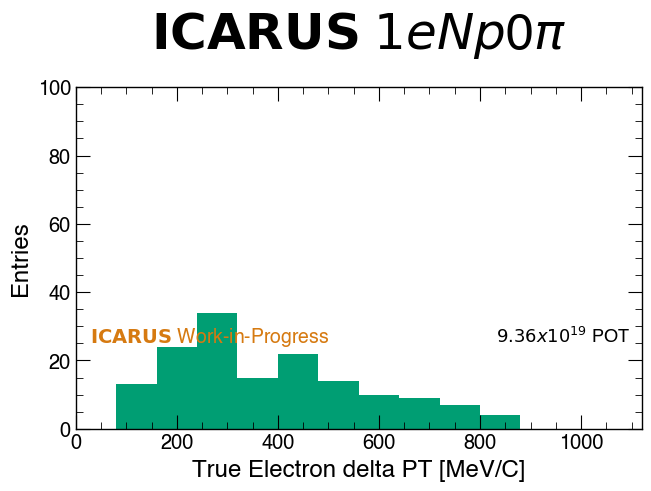

In [105]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_electron_pT_mag"
bins = [0,1120,75]

eff, var, unc = get_eff_bins_same(signal,cut_muon,variable,bins = bins)
low_error = [sublist[0] for sublist in unc]
high_error = [sublist[1] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)
x_err = []
scatter_x = []
ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')



ax1.set_xlabel("True Electron delta PT [MeV/C]")
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 100)
yrange = [0,25]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_electron_pT.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


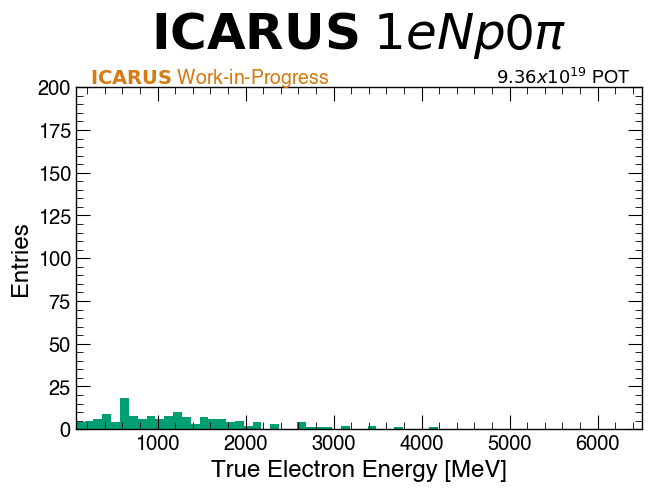

In [106]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_electron_energy"
bins = [70,6500,100]
bins_eff = [70,3970,75]


widths = [bins[2]]*len(eff)
x_err = []
scatter_x = []
ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel("True Electron Energy [MeV]")
ax2.set_ylabel("Efficiency",color = 'darkorange')
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)
yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_electron_energy.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044
280.4189588859409


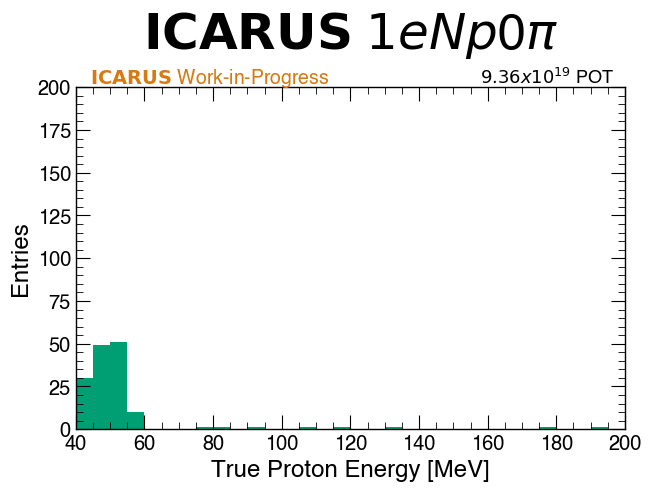

In [107]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_proton_energy"
bins = [40,200,5]
bins_eff = [40,1000,75]


widths = [bins[2]]*len(eff)
x_err = []
scatter_x = []
ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel("True Proton Energy [MeV]")
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)
yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_proton_energy.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")
print(np.max(cut_muon['true_proton_energy']))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  2.63it/s]


Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


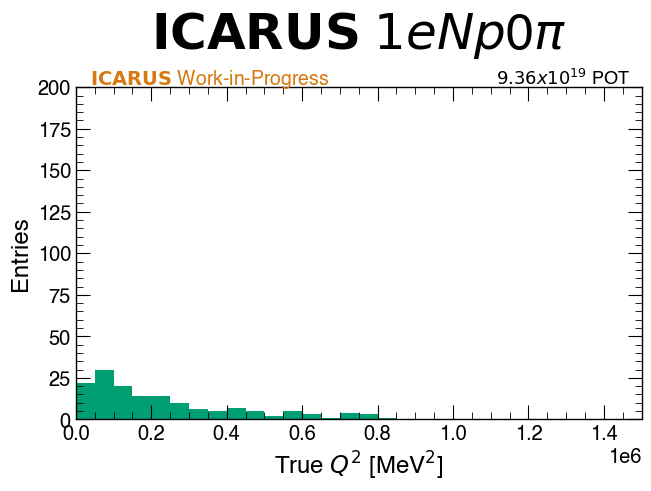

In [108]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_Q"
bins = [0,1.5e6,.5e5]
bins_eff = [0,1.5e6,50]

eff, var, unc = get_eff_bins_same(signal,cut_muon,variable,bins = bins_eff)
low_error = [sublist[0] for sublist in unc]
high_error = [sublist[1] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)
x_err = []
scatter_x = []
ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel(r"True $Q^2$ [MeV$^2$]")

ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)
yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_q_squared.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.39it/s]


Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


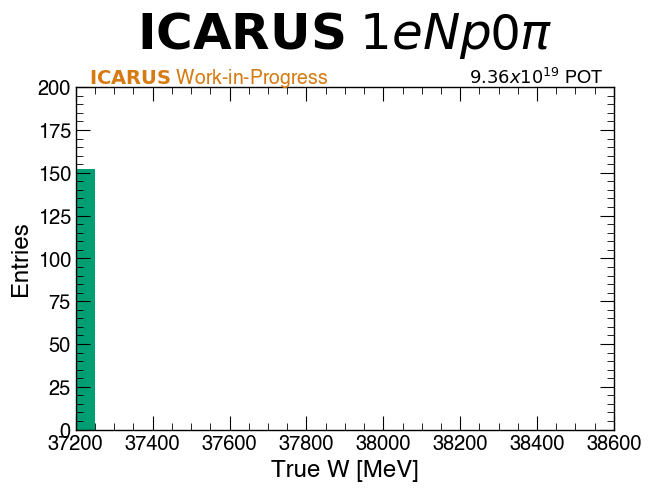

In [109]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_W"
bins = [3.72e4,3.86e4,.5e2]
bins_eff = [3.72e4,3.85e4,75]

eff, var, unc = get_eff_bins_same(signal,cut_muon,variable,bins = bins_eff)
low_error = [sublist[0] for sublist in unc]
high_error = [sublist[1] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)
x_err = []
scatter_x = []
ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel(r"True W [MeV]")
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)
yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_W.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.33it/s]


Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


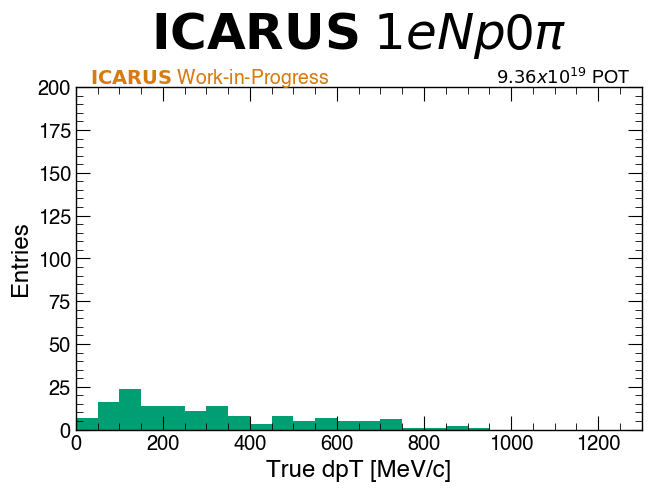

In [110]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_dpT"
bins = [0,1300,50]
bins_eff = [0,1300,75]

eff, var, unc = get_eff_bins_same(signal,cut_muon,variable,bins = bins_eff)
low_error = [sublist[0] for sublist in unc]
high_error = [sublist[1] for sublist in unc]
y_err = [np.array(low_error),np.array(high_error)]
widths = [bins[2]]*len(eff)
x_err = []
scatter_x = []
ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel(r"True dpT [MeV/c]")

ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)

yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_dpT.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


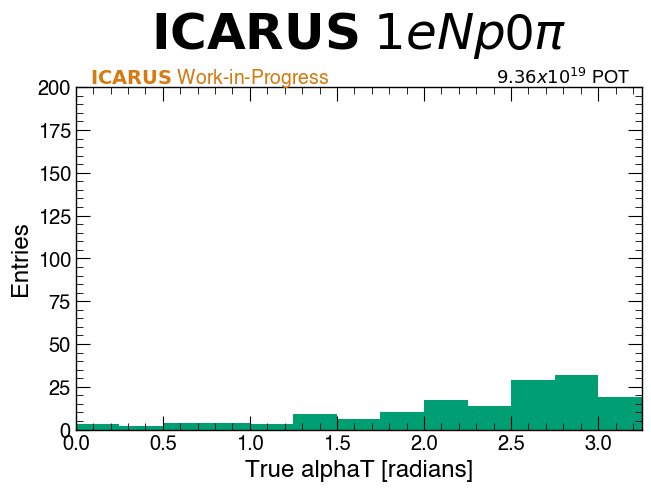

In [111]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_alphaT"
bins = [0,3.25,.25]
bins_eff = [0,3.25,75]


ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel(r"True alphaT [radians]")
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)

yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_alphaT.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


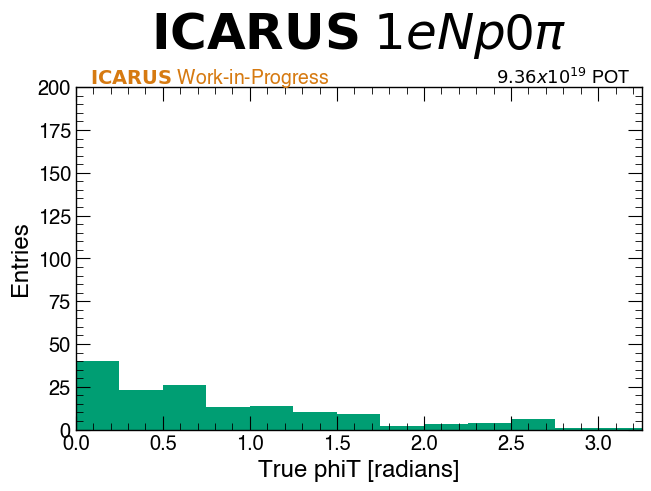

In [112]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_phiT"
bins = [0,3.25,.25]
bins_eff = [0,3.25,75]


ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel(r"True phiT [radians]")
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)
yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_phiT.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


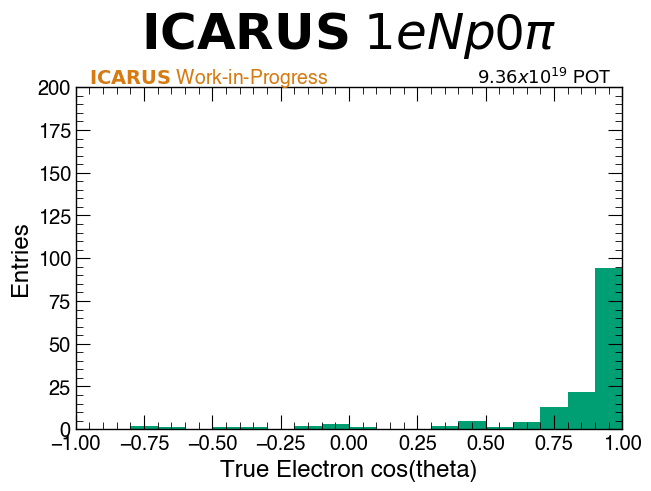

In [113]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_electron_polar"
bins = [-1,1.0,.1]
bins_eff = [0,1,75]


ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel(r"True Electron cos(theta)")
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)
yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_electron_cos_theta.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


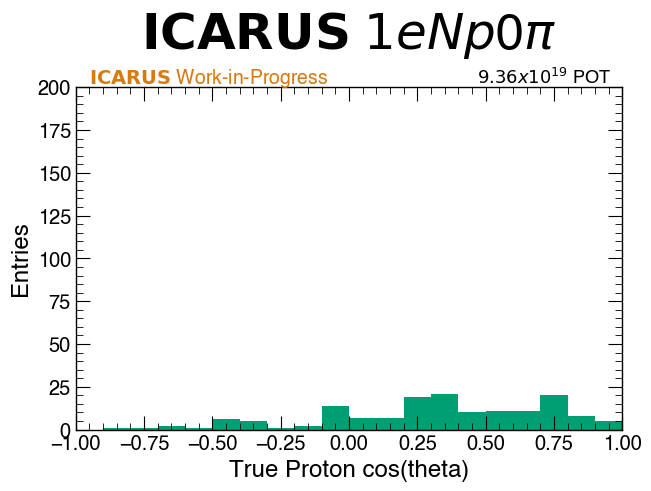

In [114]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_proton_polar"
bins = [-1,1,.1]
bins_eff = [0,1,75]


ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel(r"True Proton cos(theta)")
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)
yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_proton_cos_theta.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


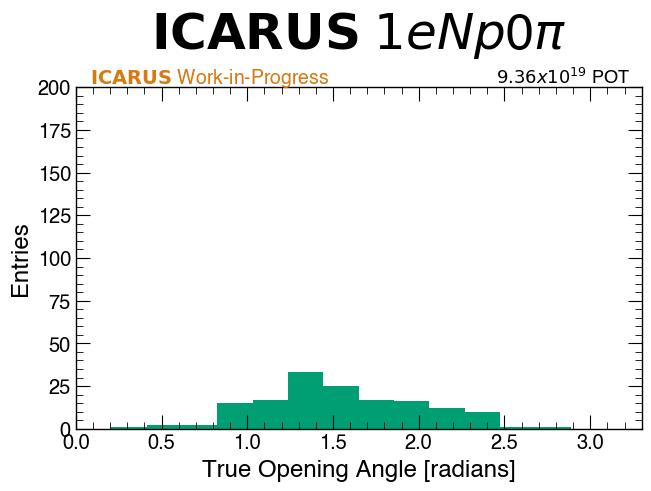

In [115]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "true_opening_angle"
bins = [0,3.3,.2]
bins_eff = [0,3.3,75]


ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel(r"True Opening Angle [radians]")
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)

yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_opening_angle.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 7044, 7044


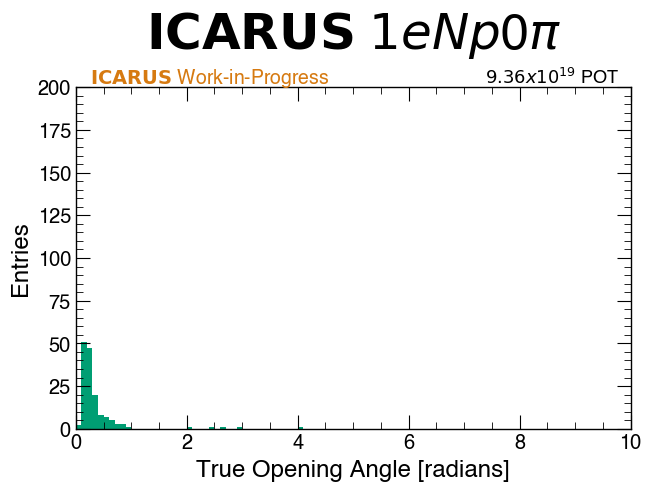

In [116]:
plt.style.use('styles/muon2024_colorswap.mplstyle')

fig, ax1 = plt.subplots()
variable = "reco_electron_conv_dist"
bins = [0,10,.1]
bins_eff = [0,3.3,75]


ax1.hist(cut_muon[variable],bins=int((bins[1]-bins[0])/bins[2]),range=(bins[0], bins[1]),color = '#009E73', label='Signal')

ax1.set_xlabel(r"True Opening Angle [radians]")
ax1.set_ylabel("Entries")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
ax1.set_ylim(0, 200)

yrange = [0,200]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$9.36x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Efficiency_plots/True_opening_angle.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")